In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import warnings
warnings.filterwarnings(
    "ignore",
    message="DataFrameGroupBy.apply operated on the grouping columns",
    category=DeprecationWarning
)

data         = pd.read_csv("./output/panel_data.csv")
adj_close    = pd.read_csv("./input/수정주가_현금배당반영.csv", index_col=0, parse_dates=True)

---
### **size, pre-beta 12 portfolio**

In [2]:
data.columns

Index(['Date', 'Ticker', 'ME', 'pre_beta', 'is_kospi', 'size_decile',
       'pre_beta_decile', 'post_beta', 'lnME', 'ln_BE_ME_con', 'ln_BE_ME_sep',
       'ln_A_ME_con', 'ln_A_ME_sep', 'ln_A_BE_con', 'ln_A_BE_sep', 'E_P_con',
       'E_P_sep', 'E_P_dummy_con', 'E_P_dummy_sep'],
      dtype='object')

In [3]:
data['pre_beta_decile_2'] = (
    data.groupby('Date', group_keys=False)
        .apply(lambda g: pd.cut(
            g['pre_beta'],
            bins=[-np.inf] + g.loc[g['is_kospi'] == 1, 'pre_beta'].quantile(np.arange(0.1, 1.0, 0.1)).tolist() + [np.inf],
            labels=range(1, 11),
            include_lowest=True
        ))
        .astype('Int64')
)

data['BE_ME_decile'] = (
    data.groupby('Date', group_keys=False)
        .apply(lambda g: pd.cut(
            g['ln_BE_ME_sep'],
            bins=[-np.inf] + g['ln_BE_ME_sep'].dropna().quantile(np.arange(0.1, 1.0, 0.1)).tolist() + [np.inf],
            labels=range(1, 11),
            include_lowest=True
        ))
        .astype('Int64')
)

In [4]:
def split_extremes(g, dec_col, sort_col):
    x = g[dec_col].astype('object').copy()

    m1 = x.eq(1)
    if m1.any():
        med1 = g.loc[m1, sort_col].median()
        x.loc[m1] = np.where(g.loc[m1, sort_col] <= med1, '1A', '1B')

    m10 = x.eq(10)
    if m10.any():
        med10 = g.loc[m10, sort_col].median()
        x.loc[m10] = np.where(g.loc[m10, sort_col] <= med10, '10A', '10B')

    return x

data['size_decile_2'] = (
    data.groupby('Date', group_keys=False)
        .apply(lambda g: split_extremes(g, 'size_decile', 'ME'))
)

data['pre_beta_decile_2'] = (
    data.groupby('Date', group_keys=False)
        .apply(lambda g: split_extremes(g, 'pre_beta_decile_2', 'pre_beta'))
)

data['BE_ME_decile_2'] = (
    data.groupby('Date', group_keys=False)
        .apply(lambda g: split_extremes(g, 'BE_ME_decile', 'ln_BE_ME_sep'))
)

In [5]:
import numpy as np
import pandas as pd

def make_ep_port(g, ep_col='E_P_sep', dummy_col='E_P_dummy_sep'):
    g = g.copy()
    out = pd.Series(pd.NA, index=g.index, dtype='object')

    neg = g[dummy_col].eq(1)                 # 적자 -> 0 포트폴리오
    pos = g[dummy_col].eq(0) & g[ep_col].notna()   # 흑자만 정렬

    out.loc[neg] = '0'

    if pos.sum() == 0:
        return out

    # 분위경계 중복 문제 피하려고 rank 기반 10분위
    r = g.loc[pos, ep_col].rank(method='first', pct=True)
    dec = np.ceil(r * 10).clip(1, 10).astype(int).astype(object)
    out.loc[pos] = dec

    # 하위 10%, 상위 10%를 다시 반으로 분할
    m1 = out.eq(1)
    if m1.any():
        med1 = g.loc[m1, ep_col].median()
        out.loc[m1] = np.where(g.loc[m1, ep_col] <= med1, '1A', '1B')

    m10 = out.eq(10)
    if m10.any():
        med10 = g.loc[m10, ep_col].median()
        out.loc[m10] = np.where(g.loc[m10, ep_col] <= med10, '10A', '10B')

    # 나머지도 문자열로 통일
    out = out.astype(str)
    return out

In [6]:
data['E_P_decile_2'] = (
    data.groupby('Date', group_keys=False)
        .apply(lambda g: make_ep_port(g, ep_col='E_P_sep', dummy_col='E_P_dummy_sep'))
)

---
### **월 패널 데이터 생성**

In [7]:
monthly_returns = adj_close.pct_change(fill_method=None)

In [8]:
target_months = monthly_returns.loc['1999-07':'2025-12'].index
target_months

DatetimeIndex(['1999-07-31', '1999-08-31', '1999-09-30', '1999-10-31',
               '1999-11-30', '1999-12-31', '2000-01-31', '2000-02-29',
               '2000-03-31', '2000-04-30',
               ...
               '2025-03-31', '2025-04-30', '2025-05-31', '2025-06-30',
               '2025-07-31', '2025-08-31', '2025-09-30', '2025-10-31',
               '2025-11-30', '2025-12-31'],
              dtype='datetime64[ns]', name='Date', length=318, freq=None)

In [9]:
data = data.copy()
data['Date'] = pd.to_datetime(data['Date'])

monthly_data = (
    data
    .sort_values(['Ticker', 'Date'])
    .groupby('Ticker', group_keys=False)
    .apply(lambda g: (
        g.set_index('Date')
         .pipe(lambda x: x.reindex(x.index.union(target_months)))
         .sort_index()
         .bfill(limit=11)
         .loc[target_months]
         .assign(Ticker=g['Ticker'].iloc[0])
    ))
    .reset_index()
    .rename(columns={'index': 'Date'})
)

In [10]:
# 1) monthly_returns를 long format으로 변환
ret_long = (
    monthly_returns
    .loc[monthly_data['Date'].min():monthly_data['Date'].max()]
    .rename_axis('Date')
    .stack(dropna=False)
    .rename('ret')
    .reset_index()
    .rename(columns={'level_1': 'Ticker'})
)

# 2) Date, Ticker 기준으로 merge
monthly_data = monthly_data.merge(
    ret_long,
    on=['Date', 'Ticker'],
    how='left'
)

In [11]:
monthly_data.to_csv("./output/monthly_panel_data.csv", index=False)

---
### **Table II**

In [12]:
def make_table(monthly_ret, data, port_col='pre_beta_decile_2', suffix='sep'):
    order = ['0','1A','1B','2','3','4','5','6','7','8','9','10A','10B'] if port_col == 'E_P_decile_2' \
            else ['1A','1B','2','3','4','5','6','7','8','9','10A','10B']

    monthly_ret = monthly_ret.copy()
    data = data.copy()

    if suffix == 'con':
        monthly_ret = monthly_ret[monthly_ret['Date'] >= '2012-07-31']
        data = data[data['Date'] >= '2013-06-30']

    monthly_ret[port_col] = monthly_ret[port_col].astype(str)
    data[port_col] = data[port_col].astype(str)

    ret = (
        monthly_ret.groupby(['Date', port_col])['ret']
        .mean().unstack().mean().mul(100).rename('Return')
    )

    beta = (
        data.groupby(['Date', port_col])['post_beta']
        .mean().unstack().mean().rename('β')
    )

    lnme = (
        data.groupby(['Date', port_col])['lnME']
        .mean().unstack().mean().rename('ln(ME)')
    )

    ln_be_me = (
        data.groupby(['Date', port_col])[f'ln_BE_ME_{suffix}']
        .mean().unstack().mean().rename('ln(BE/ME)')
    )

    ln_a_me = (
        data.groupby(['Date', port_col])[f'ln_A_ME_{suffix}']
        .mean().unstack().mean().rename('ln(A/ME)')
    )

    ln_a_be = (
        data.groupby(['Date', port_col])[f'ln_A_BE_{suffix}']
        .mean().unstack().mean().rename('ln(A/BE)')
    )

    ep_dummy = (
        data.groupby(['Date', port_col])[f'E_P_dummy_{suffix}']
        .mean().unstack().mean().rename('E/P dummy')
    )

    ep_pos = (
        data.loc[data[f'E_P_dummy_{suffix}'] == 0]
        .groupby(['Date', port_col])[f'E_P_{suffix}']
        .mean().unstack().mean().rename('E(+)/P')
    )

    firms = (
        data.groupby(['Date', port_col])['Ticker']
        .nunique().unstack().mean().rename('Firms')
    )

    table = pd.concat(
        [ret, beta, lnme, ln_be_me, ln_a_me, ln_a_be, ep_dummy, ep_pos, firms],
        axis=1
    ).T

    return table.reindex(columns=order)

In [13]:
table_beta_sep = make_table(monthly_data, data, port_col='pre_beta_decile_2', suffix='sep')
table_beta_con = make_table(monthly_data, data, port_col='pre_beta_decile_2', suffix='con')

table_size_sep = make_table(monthly_data, data, port_col='size_decile_2', suffix='sep')
table_size_con = make_table(monthly_data, data, port_col='size_decile_2', suffix='con')

In [14]:
print("Table II Panel A (sorted by ME, sep):")
round(table_size_sep, 2)

Table II Panel A (sorted by ME, sep):


size_decile_2,1A,1B,2,3,4,5,6,7,8,9,10A,10B
Return,2.88,2.26,1.46,0.79,0.58,0.53,0.55,0.46,0.78,1.10,1.01,0.90
β,0.58,0.59,0.69,0.72,0.80,0.83,0.84,0.90,0.99,1.00,1.11,1.08
ln(ME),9.43,10.03,10.44,10.82,11.16,11.49,11.85,12.27,12.84,13.70,14.70,16.04
ln(BE/ME),14.09,14.03,13.96,13.90,13.85,13.79,13.74,13.67,13.55,13.50,13.47,13.46
ln(A/ME),15.10,14.90,14.72,14.63,14.54,14.47,14.41,14.35,14.25,14.28,14.32,14.22
ln(A/BE),1.03,0.86,0.75,0.71,0.68,0.67,0.67,0.67,0.69,0.77,0.84,0.76
E/P dummy,0.61,0.50,0.40,0.33,0.29,0.26,0.22,0.21,0.18,0.16,0.13,0.09
E(+)/P,0.74,0.91,0.31,0.36,0.38,0.15,0.21,0.18,0.13,0.10,0.09,0.09
Firms,156.41,155.89,234.04,188.11,168.19,147.59,132.44,115.56,99.85,79.44,34.00,33.56


<Axes: title={'center': 'Average Monthly Return by Size Decile (sep)'}, xlabel='size_decile_2', ylabel='Average Return (%)'>

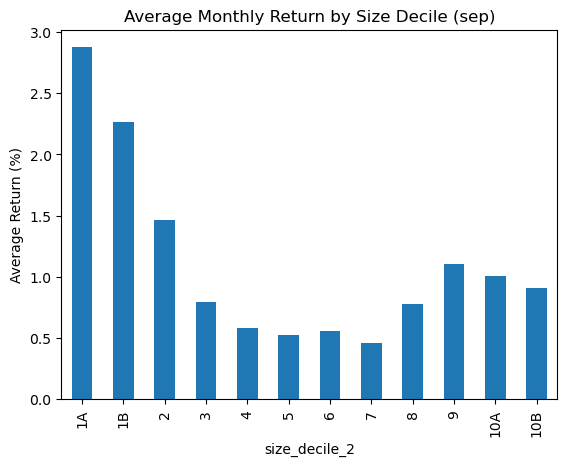

In [15]:
table_size_sep.loc['Return'].plot(kind='bar', title='Average Monthly Return by Size Decile (sep)', ylabel='Average Return (%)')

In [16]:
print("Table II Panel B (sorted by pre_beta, sep):")
round(table_beta_sep, 2)

Table II Panel B (sorted by pre_beta, sep):


pre_beta_decile_2,1A,1B,2,3,4,5,6,7,8,9,10A,10B
Return,1.02,1.29,1.43,1.42,1.47,1.45,1.34,1.28,1.53,1.11,1.01,0.84
β,0.60,0.65,0.67,0.73,0.74,0.77,0.79,0.83,0.87,0.89,0.89,0.90
ln(ME),11.07,11.32,11.38,11.38,11.31,11.37,11.37,11.47,11.44,11.44,11.37,11.32
ln(BE/ME),13.47,13.74,13.86,13.92,13.96,13.96,13.95,13.91,13.87,13.79,13.68,13.44
ln(A/ME),14.18,14.40,14.53,14.59,14.65,14.69,14.69,14.68,14.69,14.64,14.55,14.26
ln(A/BE),0.70,0.65,0.65,0.66,0.68,0.72,0.73,0.76,0.79,0.81,0.83,0.78
E/P dummy,0.43,0.30,0.28,0.26,0.27,0.27,0.29,0.31,0.32,0.36,0.41,0.48
E(+)/P,0.38,0.14,0.24,0.14,0.20,0.25,0.18,0.19,0.23,0.29,0.42,0.32
Firms,94.74,94.30,136.33,130.74,137.26,138.96,142.22,149.44,153.30,165.41,101.41,100.96


<Axes: title={'center': 'Average Monthly Return by Pre-Beta Decile (sep)'}, xlabel='pre_beta_decile_2', ylabel='Average Return (%)'>

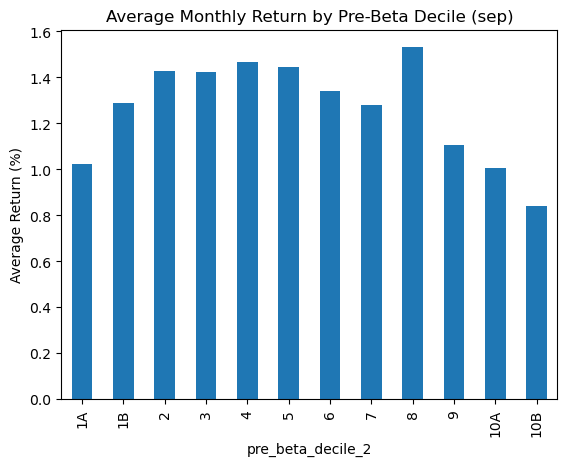

In [17]:
table_beta_sep.loc['Return'].plot(kind='bar', title='Average Monthly Return by Pre-Beta Decile (sep)', ylabel='Average Return (%)')

In [18]:
print("Table II Panel A (sorted by ME, con):")
round(table_size_con, 2)

Table II Panel A (sorted by ME, con):


size_decile_2,1A,1B,2,3,4,5,6,7,8,9,10A,10B
Return,2.29,1.60,0.78,0.46,0.31,0.46,0.54,0.56,0.64,0.94,0.35,0.67
β,0.58,0.59,0.69,0.72,0.80,0.83,0.84,0.90,0.99,1.00,1.10,1.08
ln(ME),10.15,10.71,11.08,11.45,11.77,12.10,12.45,12.89,13.48,14.31,15.27,16.56
ln(BE/ME),13.84,13.86,13.80,13.74,13.68,13.64,13.60,13.48,13.31,13.34,13.34,13.42
ln(A/ME),14.74,14.59,14.51,14.45,14.38,14.36,14.32,14.19,14.05,14.20,14.24,14.15
ln(A/BE),0.90,0.74,0.71,0.70,0.70,0.72,0.72,0.72,0.74,0.86,0.89,0.72
E/P dummy,0.66,0.50,0.41,0.35,0.30,0.29,0.24,0.21,0.19,0.17,0.17,0.09
E(+)/P,0.12,0.09,0.11,0.11,0.10,0.11,0.10,0.10,0.10,0.08,0.07,0.08
Firms,198.93,198.43,287.14,225.21,202.64,175.79,155.07,138.43,115.43,89.71,36.79,36.29


In [19]:
print("Table II Panel B (sorted by pre_beta, con):")
round(table_beta_con, 2)

Table II Panel B (sorted by pre_beta, con):


pre_beta_decile_2,1A,1B,2,3,4,5,6,7,8,9,10A,10B
Return,0.61,0.94,1.13,1.15,1.16,0.92,1.08,1.15,1.21,1.10,0.91,0.74
β,0.60,0.64,0.67,0.72,0.74,0.75,0.78,0.80,0.86,0.88,0.87,0.89
ln(ME),11.72,11.97,12.00,11.95,11.90,11.88,11.89,11.90,11.94,11.93,11.93,11.93
ln(BE/ME),13.22,13.51,13.68,13.74,13.74,13.77,13.78,13.72,13.72,13.70,13.52,13.26
ln(A/ME),13.88,14.18,14.36,14.42,14.46,14.49,14.54,14.49,14.54,14.51,14.33,14.05
ln(A/BE),0.66,0.66,0.68,0.68,0.71,0.72,0.76,0.77,0.82,0.81,0.81,0.78
E/P dummy,0.46,0.34,0.28,0.29,0.29,0.30,0.30,0.32,0.32,0.35,0.39,0.47
E(+)/P,0.09,0.09,0.10,0.11,0.11,0.10,0.10,0.10,0.10,0.11,0.09,0.09
Firms,113.29,112.64,159.36,154.86,165.36,168.71,175.14,187.79,186.29,201.43,117.71,117.29


---
### **Table III - Fama-Macbeth Regression**

In [20]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

def make_table3(monthly_data, suffix='sep'):
    df = monthly_data.copy()

    if suffix == 'con':
        df = df[df['Date'] >= '2012-07-31'].copy()

    df['ret'] = df['ret'] * 100

    winsor_cols = [f'ln_BE_ME_{suffix}', f'ln_A_ME_{suffix}', f'ln_A_BE_{suffix}', f'E_P_{suffix}']

    def winsorize_month(g):
        g = g.copy()
        for c in winsor_cols:
            s = g[c]
            if s.notna().sum() > 1:
                lo, hi = s.quantile([0.005, 0.995])
                g[c] = s.clip(lo, hi)
        return g

    df = df.groupby('Date', group_keys=False).apply(winsorize_month)

    specs = [
        ['post_beta'],
        ['lnME'],
        ['post_beta', 'lnME'],
        [f'ln_BE_ME_{suffix}'],
        [f'ln_A_ME_{suffix}', f'ln_A_BE_{suffix}'],
        [f'E_P_dummy_{suffix}', f'E_P_{suffix}'],
        ['lnME', f'ln_BE_ME_{suffix}'],
        ['lnME', f'ln_A_ME_{suffix}', f'ln_A_BE_{suffix}'],
        ['lnME', f'E_P_dummy_{suffix}', f'E_P_{suffix}'],
        ['lnME', f'ln_BE_ME_{suffix}', f'E_P_dummy_{suffix}', f'E_P_{suffix}'],
        ['lnME', f'ln_A_ME_{suffix}', f'ln_A_BE_{suffix}', f'E_P_dummy_{suffix}', f'E_P_{suffix}'],
    ]

    colmap = {
        'post_beta': 'β',
        'lnME': 'ln(ME)',
        f'ln_BE_ME_{suffix}': 'ln(BE/ME)',
        f'ln_A_ME_{suffix}': 'ln(A/ME)',
        f'ln_A_BE_{suffix}': 'ln(A/BE)',
        f'E_P_dummy_{suffix}': 'E/P Dummy',
        f'E_P_{suffix}': 'E(+)/P'
    }
    cols = ['β', 'ln(ME)', 'ln(BE/ME)', 'ln(A/ME)', 'ln(A/BE)', 'E/P Dummy', 'E(+)/P']

    def fm(g, xvars):
        x = g[['ret', *xvars]].dropna()
        out = pd.Series(np.nan, index=xvars, dtype=float)
        if len(x) <= len(xvars) + 1:
            return out
        try:
            res = sm.OLS(x['ret'], sm.add_constant(x[xvars])).fit()
            out.loc[xvars] = res.params.loc[xvars]
        except:
            pass
        return out

    rows = []
    for spec in specs:
        betas = df.groupby('Date', sort=True).apply(lambda g: fm(g, spec))
        mean = betas.mean()
        se = betas.std(ddof=1) / np.sqrt(betas.notna().sum())
        tval = mean / se

        row = pd.Series('', index=cols, dtype=object)
        for v in spec:
            if pd.notna(mean[v]) and pd.notna(tval[v]):
                row[colmap[v]] = f"{mean[v]:.2f} ({tval[v]:.2f})"
        rows.append(row)

    return pd.DataFrame(rows, index=range(1, len(specs)+1))

In [33]:
table3_sep  = make_table3(monthly_data, suffix='sep')
table3_con  = make_table3(monthly_data, suffix='con')
table3_2025 = make_table3(monthly_data[monthly_data['Date'] >= '2025-01-01'], suffix='sep')

In [22]:
print("Table III (sep):")
table3_sep

Table III (sep):


,β,ln(ME),ln(BE/ME),ln(A/ME),ln(A/BE),E/P Dummy,E(+)/P
1,-2.32 (-3.63),,,,,,
2,,-0.34 (-3.55),,,,,
3,-1.02 (-2.08),-0.25 (-2.84),,,,,
4,,,0.82 (6.45),,,,
5,,,,0.83 (6.41),-0.76 (-5.58),,
6,,,,,,-0.41 (-1.90),1.49 (2.91)
7,,-0.27 (-2.83),0.70 (5.46),,,,
8,,-0.26 (-2.74),,0.71 (5.34),-0.72 (-5.25),,
9,,-0.42 (-4.47),,,,-0.86 (-4.31),1.06 (2.03)
10,,-0.33 (-3.55),0.62 (5.13),,,-0.68 (-3.83),-0.10 (-0.22)


In [23]:
print("Table III (con):")
table3_con

Table III (con):


,β,ln(ME),ln(BE/ME),ln(A/ME),ln(A/BE),E/P Dummy,E(+)/P
1,-1.75 (-3.64),,,,,,
2,,-0.29 (-3.94),,,,,
3,-0.53 (-1.28),-0.25 (-3.38),,,,,
4,,,0.44 (3.66),,,,
5,,,,0.43 (3.59),-0.56 (-4.15),,
6,,,,,,-0.21 (-1.28),1.15 (1.61)
7,,-0.19 (-2.54),0.35 (2.91),,,,
8,,-0.19 (-2.55),,0.34 (2.82),-0.49 (-3.56),,
9,,-0.28 (-3.91),,,,-0.49 (-3.22),0.69 (0.94)
10,,-0.24 (-3.28),0.29 (2.46),,,-0.48 (-3.25),-0.33 (-0.52)


In [34]:
print("Table III (2025):")
table3_2025

Table III (2025):


,β,ln(ME),ln(BE/ME),ln(A/ME),ln(A/BE),E/P Dummy,E(+)/P
1,3.73 (1.73),,,,,,
2,,0.50 (1.62),,,,,
3,2.26 (1.38),0.28 (1.06),,,,,
4,,,0.00 (0.01),,,,
5,,,,0.02 (0.07),0.50 (1.22),,
6,,,,,,-0.20 (-0.36),3.65 (1.13)
7,,0.51 (1.72),0.15 (0.46),,,,
8,,0.51 (1.69),,0.17 (0.52),0.30 (0.80),,
9,,0.49 (1.59),,,,0.20 (0.42),4.18 (1.38)
10,,0.49 (1.58),-0.03 (-0.08),,,0.22 (0.48),4.22 (1.33)


---
### **Table IV**

In [24]:
print("Table IV Panel A (sorted by ME, sep):")
table_BE_ME_sep = make_table(monthly_data, data, port_col='BE_ME_decile_2', suffix='sep')
round(table_BE_ME_sep, 2)

Table IV Panel A (sorted by ME, sep):


BE_ME_decile_2,1A,1B,2,3,4,5,6,7,8,9,10A,10B
Return,-0.26,0.01,0.71,1.01,1.20,1.04,1.41,1.53,1.85,1.80,2.11,2.14
β,0.86,0.85,0.82,0.81,0.79,0.77,0.77,0.77,0.76,0.76,0.77,0.75
ln(ME),11.97,11.93,11.75,11.60,11.51,11.35,11.28,11.26,11.13,11.09,11.10,10.95
ln(BE/ME),11.78,12.56,12.96,13.31,13.57,13.78,13.98,14.18,14.39,14.64,14.91,15.33
ln(A/ME),13.01,13.39,13.71,14.01,14.24,14.44,14.64,14.85,15.09,15.33,15.63,16.07
ln(A/BE),1.23,0.82,0.75,0.70,0.67,0.66,0.66,0.67,0.69,0.68,0.72,0.74
E/P dummy,0.60,0.45,0.39,0.35,0.28,0.27,0.25,0.23,0.24,0.24,0.25,0.33
E(+)/P,0.11,0.08,0.08,0.08,0.11,0.11,0.14,0.16,0.19,0.21,0.32,2.00
Firms,76.56,76.04,151.96,151.85,152.07,152.19,151.70,152.00,151.93,151.89,76.52,75.96


<Axes: title={'center': 'Average Monthly Return by BE/ME Decile (sep)'}, xlabel='BE_ME_decile_2', ylabel='Average Return (%)'>

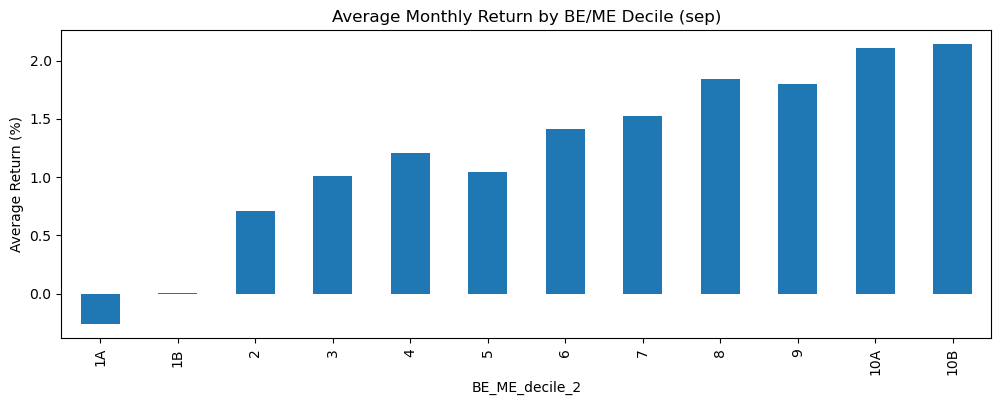

In [25]:
table_BE_ME_sep.loc['Return'].plot(kind='bar', title='Average Monthly Return by BE/ME Decile (sep)', figsize=(12, 4), ylabel='Average Return (%)')

In [26]:
print("Table IV Panel B (sorted by E/P, sep):")
table_E_P_sep = make_table(monthly_data, data, port_col='E_P_decile_2', suffix='sep')
round(table_E_P_sep, 2)

Table IV Panel B (sorted by E/P, sep):


E_P_decile_2,0,1A,1B,2,3,4,5,6,7,8,9,10A,10B
Return,0.85,1.14,0.76,1.24,1.18,1.25,1.30,1.46,1.45,1.72,1.67,1.89,2.10
β,0.74,0.82,0.82,0.81,0.82,0.82,0.81,0.81,0.80,0.80,0.79,0.79,0.78
ln(ME),10.82,11.61,11.54,11.65,11.79,11.81,11.75,11.72,11.64,11.58,11.45,11.33,11.17
ln(BE/ME),13.60,13.34,13.48,13.57,13.66,13.71,13.81,13.91,14.05,14.16,14.29,14.48,14.58
ln(A/ME),14.60,13.98,14.12,14.20,14.28,14.32,14.41,14.50,14.65,14.76,14.93,15.19,15.48
ln(A/BE),0.95,0.64,0.64,0.64,0.62,0.61,0.60,0.59,0.60,0.60,0.63,0.71,0.91
E/P dummy,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
E(+)/P,NaN,0.01,0.02,0.03,0.05,0.06,0.08,0.10,0.12,0.16,0.21,0.31,2.67
Firms,500.56,51.96,51.44,104.07,103.85,104.11,104.04,103.81,103.96,104.00,103.93,52.41,51.96


<Axes: title={'center': 'Average Monthly Return by E/P Decile (sep)'}, xlabel='E_P_decile_2', ylabel='Average Return (%)'>

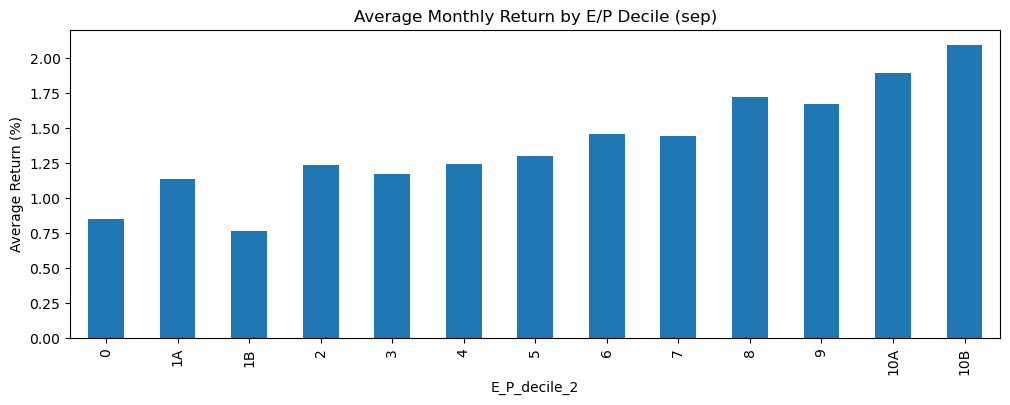

In [27]:
table_E_P_sep.loc['Return'].plot(kind='bar', title='Average Monthly Return by E/P Decile (sep)', figsize=(12, 4), ylabel='Average Return (%)')

In [28]:
print("Table IV Panel A (sorted by ME, con):")
table_BE_ME_con = make_table(monthly_data, data, port_col='BE_ME_decile_2', suffix='con')
round(table_BE_ME_con, 2)

Table IV Panel A (sorted by ME, con):


BE_ME_decile_2,1A,1B,2,3,4,5,6,7,8,9,10A,10B
Return,0.36,0.46,0.83,0.89,1.00,1.04,1.26,1.01,1.38,1.12,1.49,1.31
β,0.87,0.83,0.81,0.79,0.77,0.75,0.76,0.76,0.75,0.76,0.77,0.75
ln(ME),12.66,12.39,12.19,12.04,11.97,11.83,11.78,11.77,11.64,11.69,11.73,11.61
ln(BE/ME),11.63,12.36,12.75,13.10,13.36,13.59,13.79,13.99,14.21,14.46,14.72,15.11
ln(A/ME),12.62,13.17,13.51,13.84,14.07,14.30,14.49,14.70,14.95,15.19,15.49,15.87
ln(A/BE),0.99,0.81,0.76,0.74,0.71,0.71,0.70,0.71,0.74,0.73,0.77,0.76
E/P dummy,0.60,0.49,0.43,0.37,0.31,0.31,0.28,0.26,0.27,0.26,0.27,0.34
E(+)/P,0.03,0.03,0.05,0.06,0.07,0.08,0.08,0.11,0.13,0.14,0.18,0.21
Firms,93.07,92.64,185.07,185.07,185.14,185.43,184.79,185.14,185.07,185.07,93.00,92.57


<Axes: title={'center': 'Average Monthly Return by BE/ME Decile (con)'}, xlabel='BE_ME_decile_2', ylabel='Average Return (%)'>

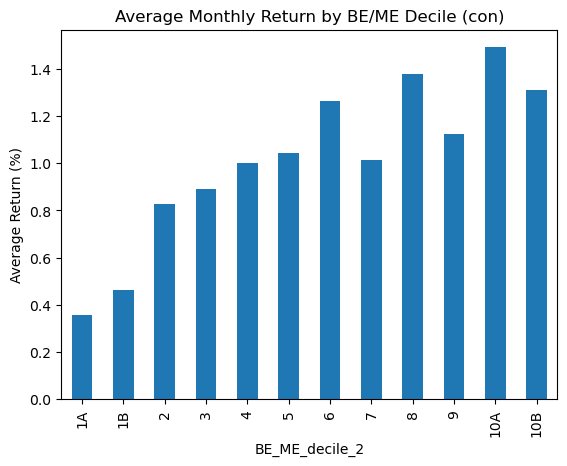

In [29]:
table_BE_ME_con.loc['Return'].plot(kind='bar', title='Average Monthly Return by BE/ME Decile (con)', ylabel='Average Return (%)')

In [30]:
print("Table IV Panel B (sorted by E/P, con):")
table_E_P_con = make_table(monthly_data, data, port_col='E_P_decile_2', suffix='con')
round(table_E_P_con, 2)

Table IV Panel B (sorted by E/P, con):


E_P_decile_2,0,1A,1B,2,3,4,5,6,7,8,9,10A,10B
Return,0.81,1.08,0.65,1.01,1.08,1.01,1.12,1.23,1.20,1.10,1.18,1.19,1.46
β,0.73,0.81,0.81,0.80,0.81,0.80,0.80,0.80,0.80,0.79,0.79,0.79,0.77
ln(ME),11.43,12.14,12.13,12.19,12.25,12.22,12.23,12.17,12.17,12.11,12.01,11.99,11.84
ln(BE/ME),13.45,13.24,13.27,13.33,13.44,13.52,13.62,13.73,13.84,14.02,14.16,14.36,14.46
ln(A/ME),14.37,13.92,13.93,13.98,14.09,14.14,14.25,14.36,14.48,14.66,14.82,15.07,15.27
ln(A/BE),0.92,0.68,0.66,0.66,0.65,0.62,0.63,0.63,0.64,0.65,0.67,0.71,0.81
E/P dummy,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
E(+)/P,0.09,0.00,0.01,0.02,0.03,0.05,0.06,0.08,0.09,0.12,0.16,0.21,0.53
Firms,619.43,61.93,61.43,124.07,123.86,124.00,124.00,123.86,123.79,124.07,123.86,62.36,61.93


<Axes: title={'center': 'Average Monthly Return by E/P Decile (con)'}, xlabel='E_P_decile_2', ylabel='Average Return (%)'>

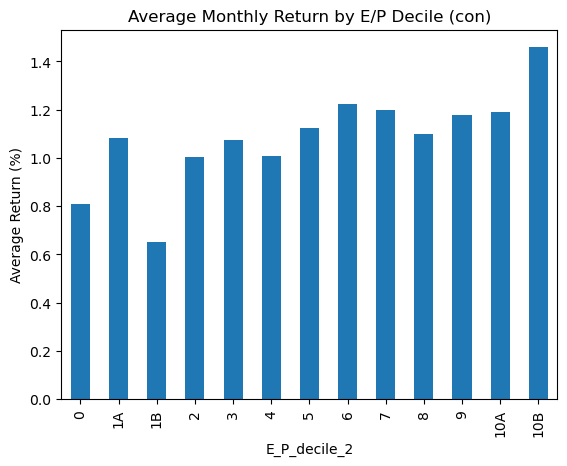

In [31]:
table_E_P_con.loc['Return'].plot(kind='bar', title='Average Monthly Return by E/P Decile (con)', ylabel='Average Return (%)')